In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [109]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [110]:
df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [111]:
df['sex'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [112]:
df['children'].unique()

array([0, 1, 3, 2, 5, 4])

In [113]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [115]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


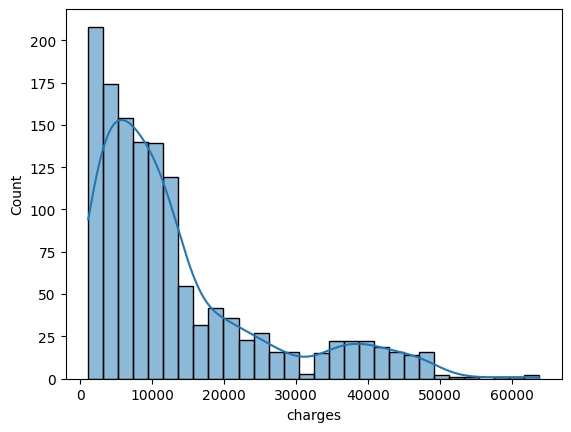

In [116]:
sns.histplot(df['charges'], kde=True)
plt.show()

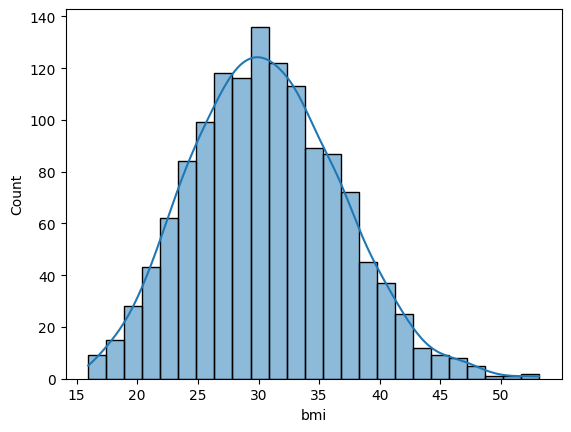

In [117]:
sns.histplot(df['bmi'], kde=True)
plt.show()

In [118]:
df.groupby('region')['charges'].mean()

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [119]:
df.groupby('region')['charges'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.0,13406.384516,11255.803066,1694.7964,5194.322288,10057.652025,16687.3641,58571.07448
northwest,325.0,12417.575374,11072.276928,1621.3402,4719.736550,8965.795750,14711.7438,60021.39897
southeast,364.0,14735.411438,13971.098589,1121.8739,4440.886200,9294.131950,19526.2869,63770.42801
southwest,325.0,12346.937377,11557.179101,1241.5650,4751.070000,8798.593000,13462.5200,52590.82939


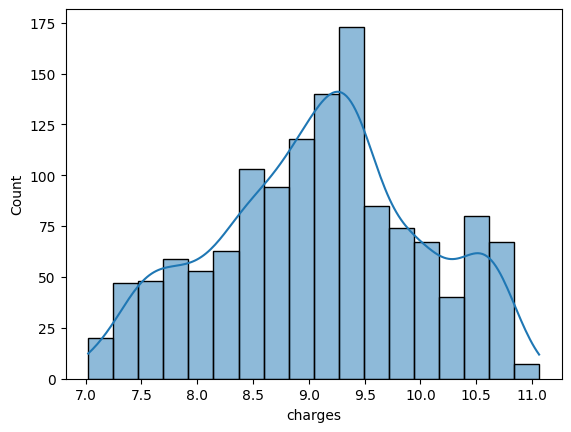

In [120]:
df['charges'] = df['charges'].apply(lambda x: np.log1p(x))
sns.histplot(df['charges'], kde=True)
plt.show()

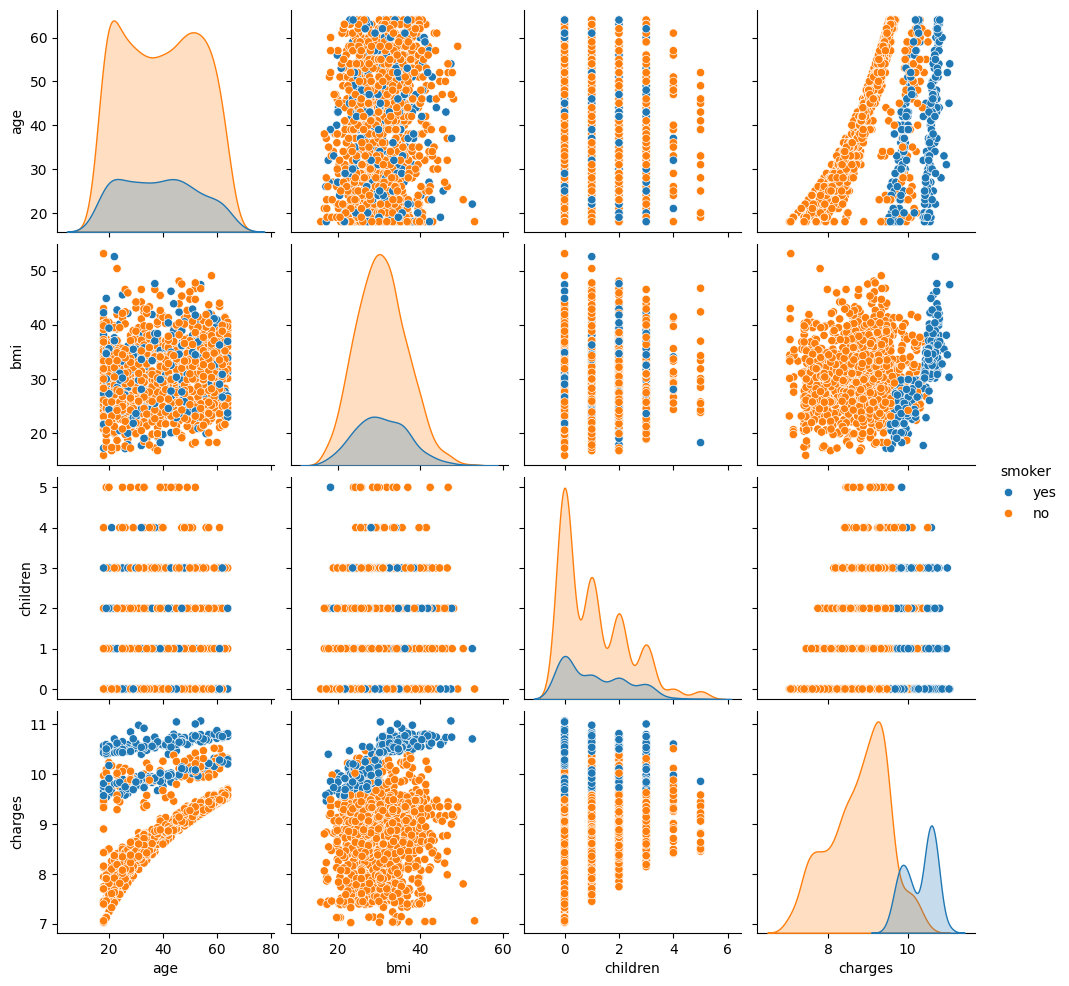

In [121]:
sns.pairplot(df, hue='smoker')

In [122]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,9.734236
1,18,male,33.770,1,no,southeast,7.453882
2,28,male,33.000,3,no,southeast,8.400763
3,33,male,22.705,0,no,northwest,9.998137
4,32,male,28.880,0,no,northwest,8.260455


In [123]:
# feature engineering
df['age_squared'] = df['age'] ** 2

df['smoker_age'] = (df['smoker'] == 'yes').astype(int) * df['age']
df['smoker_bmi'] = (df['smoker'] == 'yes').astype(int) * df['bmi']

In [124]:
df.head()

,age,sex,bmi,children,smoker,region,charges,age_squared,smoker_age,smoker_bmi
0,19,female,27.900,0,yes,southwest,9.734236,361,19,27.9
1,18,male,33.770,1,no,southeast,7.453882,324,0,0.0
2,28,male,33.000,3,no,southeast,8.400763,784,0,0.0
3,33,male,22.705,0,no,northwest,9.998137,1089,0,0.0
4,32,male,28.880,0,no,northwest,8.260455,1024,0,0.0


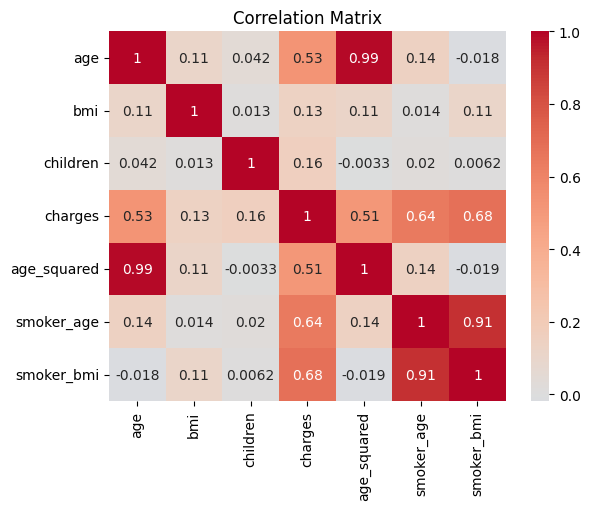

In [125]:
# Correlation heatmap
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [126]:
X = df.drop('charges', axis=1)
y = df['charges']

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
numeric_features = ['age', 'bmi', 'children', 'age_squared', 'smoker_age', 'smoker_bmi']
binary_features = ['sex', 'smoker']
multi_class_features = ['region']

preprocessor = ColumnTransformer(
    [
        ('num', RobustScaler(), numeric_features),
        ('binary', OneHotEncoder(drop='if_binary'), binary_features),
        ('multi', OneHotEncoder(drop='first'), multi_class_features)
    ]
)

In [129]:
models = {
    'LinearRegression': 
    {
        'pipe': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
        'params': {}
    },

    'RandomForest':
    {
        'pipe': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42))]),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5]
        }
    },

    'GradientBoosting': 
    {
        'pipe': Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(random_state=42))]),
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.01, 0.1, 0.2]
        }
    },

    'XGBRegressor':
    {
        'pipe': Pipeline([('prep', preprocessor), ('model', XGBRegressor(random_state=42))]),
        'params': {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [3, 5, 7],
            'model__learning_rate': [0.01, 0.1, 0.2],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0]
        }
    }
}

In [130]:
# GridSearchCV

result = {}
best_model = None
best_test_score = -np.inf

for name, config in models.items():

    print(f'Training {name}...')

    grid = GridSearchCV(
        config['pipe'],
        config['params'],
        cv = 5,
        scoring = 'r2',
        n_jobs = -1
    )

    grid.fit(X_train, y_train)

    y_pred = grid.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    

    result[name] = {
        'cv_r2': grid.best_score_,
        'test_r2': test_r2,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'best_params': grid.best_params_,
        'model': grid
    }
    
    if test_r2 > best_test_score:
        best_test_score = test_r2
        best_model = grid

    print(f' {name} - CV R2: {grid.best_score_:.4f}, Test R2: {test_r2:.4f}, Test MAE: {test_mae:.4f}, Test RMSE: {test_rmse:.4f}')

Training LinearRegression...
 LinearRegression - CV R2: 0.8135, Test R2: 0.8542, Test MAE: 0.2040, Test RMSE: 0.3621
Training RandomForest...
 RandomForest - CV R2: 0.8066, Test R2: 0.8495, Test MAE: 0.1977, Test RMSE: 0.3678
Training GradientBoosting...
 GradientBoosting - CV R2: 0.8127, Test R2: 0.8664, Test MAE: 0.1835, Test RMSE: 0.3465
Training XGBRegressor...
 XGBRegressor - CV R2: 0.8197, Test R2: 0.8565, Test MAE: 0.2074, Test RMSE: 0.3592


In [132]:
# summary table

summary = []

for name, r in result.items():
    summary.append({
        'Model': name,
        'CV R2': r['cv_r2'],
        'Test R2': r['test_r2'],
        "Test MAE": r['test_mae'],
        "Test RMSE": r['test_rmse']
    })

results_df = pd.DataFrame(summary)
results_df = results_df.set_index('Model')
results_df = results_df.sort_values('Test R2', ascending=False)
results_df

,CV R2,Test R2,Test MAE,Test RMSE
Model,,,,
GradientBoosting,0.812677,0.866425,0.183526,0.346503
XGBRegressor,0.819708,0.856459,0.207379,0.359197
LinearRegression,0.813455,0.854164,0.203958,0.362057
RandomForest,0.806567,0.849460,0.197687,0.367849


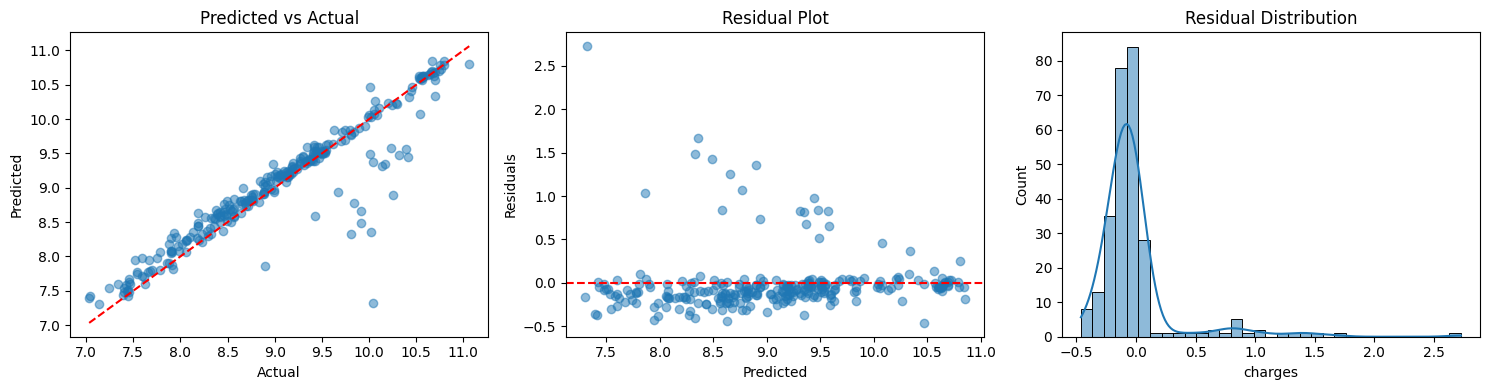

In [133]:
y_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual')

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

# Residual distribution
sns.histplot(residuals, kde=True, ax=axes[2])
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

In [134]:
X_test.head()

,age,sex,bmi,children,smoker,region,age_squared,smoker_age,smoker_bmi
764,45,female,25.175,2,no,northeast,2025,0,0.000
887,36,female,30.020,0,no,northwest,1296,0,0.000
890,64,female,26.885,0,yes,northwest,4096,64,26.885
1293,46,male,25.745,3,no,northwest,2116,0,0.000
259,19,male,31.920,0,yes,northwest,361,19,31.920


In [136]:
# predicting on new data

new_person = pd.DataFrame({
    'age': [35],
    'sex': ['male'],
    'bmi': [28.5],
    'children': [2],
    'smoker': ['yes'],
    'region': ['northwest'],
    'age_squared': [35**2],
    'smoker_age': [1*35],
    'smoker_bmi': [1*28.5]
})

pred_log = best_model.predict(new_person)
pred = np.expm1(pred_log)

print(f'Predicted insurance charge: ${pred[0]:.2f}')

Predicted insurance charge: $21982.81


In [107]:
import pickle

pickle_model_path = 'model.pkl'
with open(pickle_model_path, 'wb') as f:
    pickle.dump(best_model, f)